In [1]:
#loading dfs
import os
import pandas as pd
from pathlib import Path
p2 = Path("..") / "1_Source_Files" / "df_final_web_data_pt_1.txt"
df2 = pd.read_csv(p2, sep=",", encoding="utf-8", engine="python") 

p3 = Path("..") / "1_Source_Files" / "df_final_web_data_pt_2.txt"
df3 = pd.read_csv(p3, sep=",", encoding="utf-8", engine="python") 

pC = Path("..") / "1.1_Clean_Files" / "df_final_experiment_clients_clean.csv"
dfC = pd.read_csv(pC, sep=",", encoding="utf-8", engine="python") 

pD = Path("..") / "1.1_Clean_Files" / "df1_demo_clean.csv"
dfD = pd.read_csv(pD, sep=",", encoding="utf-8", engine="python") 

In [2]:
#visual check 1.1_Clean_Files\df_final_experiment_clients_clean.csv
df2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [3]:
#visual check
df3.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [4]:
#merging vertically dfs into df4
df4 = pd.concat([df2, df3], ignore_index=True)
df4 = df4.drop_duplicates()
df4.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [5]:
#visual check 
df4.info()

<class 'pandas.DataFrame'>
Index: 744641 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     744641 non-null  int64
 1   visitor_id    744641 non-null  str  
 2   visit_id      744641 non-null  str  
 3   process_step  744641 non-null  str  
 4   date_time     744641 non-null  str  
dtypes: int64(1), str(4)
memory usage: 34.1 MB


In [6]:
#visual check
df4.isnull()

,client_id,visitor_id,visit_id,process_step,date_time
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
755400,False,False,False,False,False
755401,False,False,False,False,False
755402,False,False,False,False,False
755403,False,False,False,False,False


In [7]:
#cleaning and norilizing data
df4['client_id'] = df4['client_id'].astype(str).str.strip()
dfD['client_id'] = df4['client_id'].astype(str).str.strip()
df4['date_time'] = pd.to_datetime(df4['date_time'], errors='coerce')  

In [8]:
#cleaning and norilizing data
for text in ['visitor_id', 'visit_id', 'process_step']:
    if text in df4.columns:
        df4[text] = df4[text].astype(str).str.strip()

In [9]:
output_path = "../1.1_Clean_Files/df4_final_web_data_clean.csv"

df4.to_csv(output_path, index=False)


In [10]:
#visual check
df4 = df4.dropna(subset=['client_id', 'date_time'], how='any')

In [11]:
#visual check
print(df4.head())
print('rows:', len(df4))

  client_id            visitor_id                      visit_id process_step  \
0   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
1   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
2   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
3   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
4   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   

            date_time  
0 2017-04-17 15:27:07  
1 2017-04-17 15:26:51  
2 2017-04-17 15:19:22  
3 2017-04-17 15:19:13  
4 2017-04-17 15:18:04  
rows: 744641


In [12]:
#visual check for understanding
id_val = 9988021
date_val = "2017-04-17" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4[(df4['client_id'] == id_s) & (df4['date_time'].dt.date == target)]
print(result)

  client_id            visitor_id                      visit_id process_step  \
0   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
1   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
2   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
3   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
4   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
5   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
6   9988021  580560515_7732621733  781255054_21935453173_531117       step_1   
7   9988021  580560515_7732621733  781255054_21935453173_531117        start   

            date_time  
0 2017-04-17 15:27:07  
1 2017-04-17 15:26:51  
2 2017-04-17 15:19:22  
3 2017-04-17 15:19:13  
4 2017-04-17 15:18:04  
5 2017-04-17 15:17:15  
6 2017-04-17 15:17:01  
7 2017-04-17 15:16:22  


In [13]:
#visual check for understanding
id_val = 763412
#id_val = 6019349
date_val = "2017-06-06" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4[df4['client_id'] == id_s]
display(result)

,client_id,visitor_id,visit_id,process_step,date_time
343141,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
343322,763412,601952081_10457207388,275115855_33219234532_879732,confirm,2017-06-02 09:37:04
343323,763412,601952081_10457207388,275115855_33219234532_879732,step_3,2017-06-02 09:35:50
343324,763412,601952081_10457207388,275115855_33219234532_879732,step_2,2017-06-02 09:35:13
343325,763412,601952081_10457207388,275115855_33219234532_879732,step_1,2017-06-02 09:34:41
343326,763412,601952081_10457207388,275115855_33219234532_879732,start,2017-06-02 09:33:47


In [14]:
#visual check for understanding
id_val = 9988021
date_val = "2017-04-17" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result2 = df4[df4['process_step'] == "confirm" ]
display(result2)

,client_id,visitor_id,visit_id,process_step,date_time
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:03
14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:01
15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:28:52
24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17 12:02:42
...,...,...,...,...,...
755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03 11:49:32
755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04 10:21:23
755375,2443347,818414719_69544570654,148166449_67114410166_524360,confirm,2017-05-30 19:18:18
755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15 19:55:09


In [15]:

dfC.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [16]:
client_id = 9988021
id_s = str(client_id)
target = pd.to_datetime(date_val).date()
result = dfC[dfC['client_id'] == id_s]
display(result)

,client_id,Variation


In [17]:
dfC['client_id'] = dfC['client_id'].astype(str)
df4C = df4.merge(dfC[['client_id','Variation']], on='client_id', how='left')

In [18]:
#visual check for understanding
id_val = 763412
#id_val = 6019349
date_val = "2017-06-06" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4C[df4C['client_id'] == id_s]
display(result)

,client_id,visitor_id,visit_id,process_step,date_time,Variation
341046,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00,NaN
341225,763412,601952081_10457207388,275115855_33219234532_879732,confirm,2017-06-02 09:37:04,NaN
341226,763412,601952081_10457207388,275115855_33219234532_879732,step_3,2017-06-02 09:35:50,NaN
341227,763412,601952081_10457207388,275115855_33219234532_879732,step_2,2017-06-02 09:35:13,NaN
341228,763412,601952081_10457207388,275115855_33219234532_879732,step_1,2017-06-02 09:34:41,NaN
341229,763412,601952081_10457207388,275115855_33219234532_879732,start,2017-06-02 09:33:47,NaN


In [19]:

dfC_agg = dfC.sort_values('client_id').groupby('client_id', as_index=False)['Variation'].first()

df4_with_variation = df4.merge(dfC_agg, on='client_id', how='inner')

# report counts
print("original df4 rows:", len(df4))
print("rows with assigned variation:", len(df4_with_variation))


original df4 rows: 744641
rows with assigned variation: 443897


In [20]:
output_path = "../1.1_Clean_Files/final_web_data_plus_experiments_clients.csv"

df4_with_variation.to_csv(output_path, index=False)


In [21]:
df5 = df4_with_variation

In [22]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     443897 non-null  str           
 1   visitor_id    443897 non-null  str           
 2   visit_id      443897 non-null  str           
 3   process_step  443897 non-null  str           
 4   date_time     443897 non-null  datetime64[us]
 5   Variation     443897 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 20.3 MB


In [23]:
df5.Variation.unique()

<StringArray>
['Test', 'Control', 'empty']
Length: 3, dtype: str

In [24]:
df5[df5['Variation'] == 'Test']

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test
...,...,...,...,...,...,...
413009,1574008,117364417_77840596075,528720790_71583064618_169151,confirm,2017-05-06 23:51:05,Test
413010,1574008,117364417_77840596075,528720790_71583064618_169151,step_3,2017-05-06 23:50:40,Test
413011,1574008,117364417_77840596075,528720790_71583064618_169151,step_2,2017-05-06 23:43:47,Test
413012,1574008,117364417_77840596075,528720790_71583064618_169151,step_1,2017-05-06 23:43:34,Test


In [25]:
df5[df5['client_id'] == '1702']

,client_id,visitor_id,visit_id,process_step,date_time,Variation
185001,1702,470573753_93844895765,243444359_78696078676_118990,confirm,2017-04-01 11:44:04,Test
394922,1702,470573753_93844895765,825109778_55379502512_27372,confirm,2017-06-05 12:04:58,Test
394923,1702,470573753_93844895765,733093772_49185493415_662403,confirm,2017-06-11 09:47:25,Test


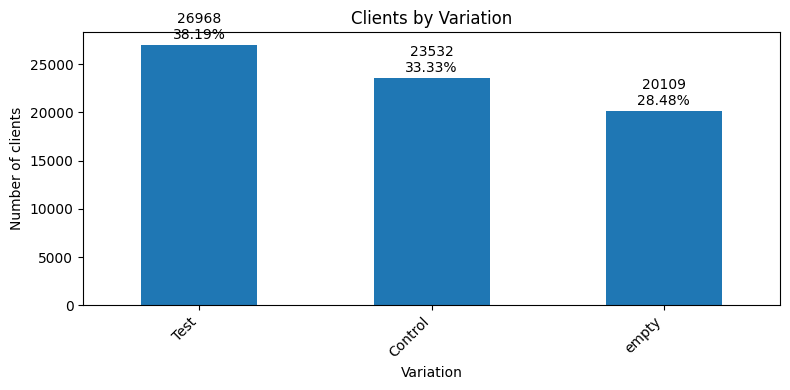

In [26]:
import matplotlib.pyplot as plt

# counts of unique clients by Variation
counts = df5.drop_duplicates('client_id')['Variation'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8,4))
counts.plot(kind='bar', color='C0', ax=ax)

total = counts.sum()
for x, v in enumerate(counts):
    ax.text(x, v + total*0.005, f"{v}\n{v/total*100:.2f}%", ha='center', va='bottom')

ax.set_xlabel('Variation')
ax.set_ylabel('Number of clients')
ax.set_title('Clients by Variation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [27]:
df5.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '7598995',  '988886', '8973570', '9979751',  '104557', '4899619', '1672289',
 '1020453', '3897324', '9895983']
Length: 70609, dtype: str

In [28]:
pC = Path("..") / "1.1_Clean_Files" / "df_final_experiment_clients_clean.csv"
dfC44 = pd.read_csv(pC, sep=",", encoding="utf-8", engine="python") 

pD = Path("..") / "1.1_Clean_Files" / "df1_demo_clean.csv"
dfD44 = pd.read_csv(pD, sep=",", encoding="utf-8", engine="python") 

In [29]:

dfC_agg = dfC44.groupby('client_id', as_index=False)['Variation'].first()

dfD_with_variation = dfD44.merge(dfC_agg, on='client_id', how='inner')

# report counts
print("original df4 rows:", len(dfD44))
print("rows with assigned variation:", len(dfD_with_variation))

original df4 rows: 70595
rows with assigned variation: 70595


In [30]:
dfD_with_variation[dfD_with_variation["client_id"] == 4033851]

,client_id,client_tenure_years,client_tenure_months,client_age,gender,number_accounts,balance,calls_6_months,logons_6_months,Variation
23518,4033851,12,149,63.5,Male,2,142642.26,5,8,Control


In [33]:
df6=dfD_with_variation

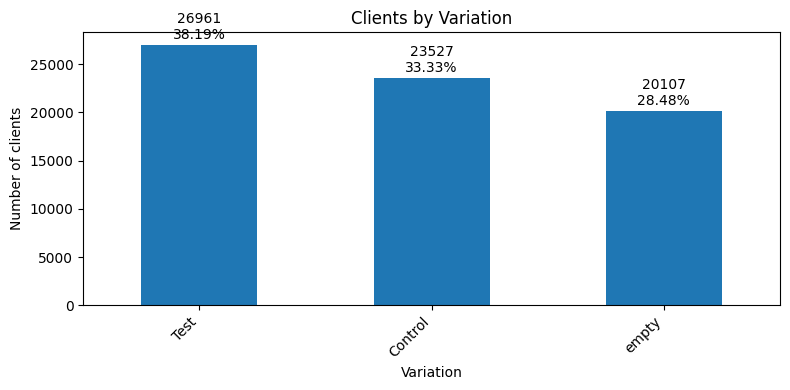

In [34]:
import matplotlib.pyplot as plt

# counts of unique clients by Variation
counts = df6.drop_duplicates('client_id')['Variation'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8,4))
counts.plot(kind='bar', color='C0', ax=ax)

total = counts.sum()
for x, v in enumerate(counts):
    ax.text(x, v + total*0.005, f"{v}\n{v/total*100:.2f}%", ha='center', va='bottom')

ax.set_xlabel('Variation')
ax.set_ylabel('Number of clients')
ax.set_title('Clients by Variation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
df6.client_id.unique()

array([ 836976, 2304905, 1439522, ...,  333913, 1573142, 5602139],
      shape=(70595,))

In [36]:
dfC.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '5217934', '1020453', '9722009', '3897324',  '687702', '2443347', '8788427',
  '266828', '1266421', '9895983']
Length: 70609, dtype: str

In [37]:
output_path = "../1.1_Clean_Files/df1_demo_clean_plus_experiments_clients.csv"

df6.to_csv(output_path, index=False)

In [38]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     443897 non-null  str           
 1   visitor_id    443897 non-null  str           
 2   visit_id      443897 non-null  str           
 3   process_step  443897 non-null  str           
 4   date_time     443897 non-null  datetime64[us]
 5   Variation     443897 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 20.3 MB


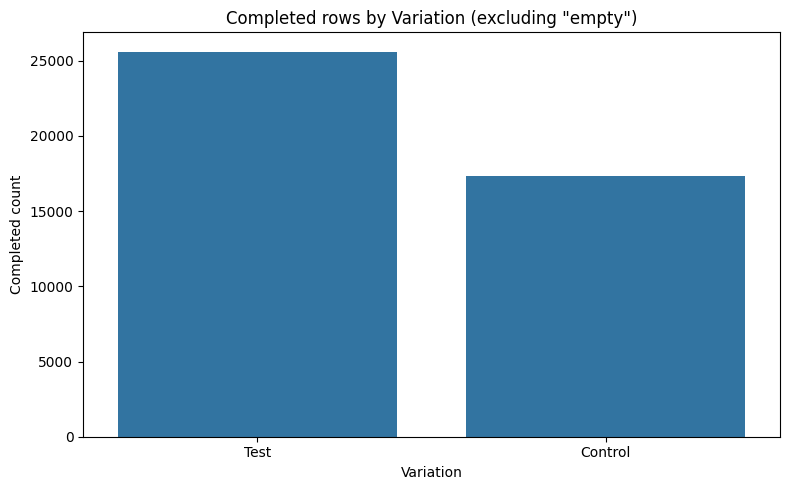

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_filtered = df5[df5['Variation'].str.lower() != 'empty']

completed = df_filtered[df_filtered['process_step'] == 'confirm']
counts = completed.groupby('Variation').size().reset_index(name='completed_count')

# plot
plt.figure(figsize=(8,5))
sns.barplot(data=counts, x='Variation', y='completed_count',
            order=counts.sort_values('completed_count', ascending=False)['Variation'])
plt.title('Completed rows by Variation (excluding "empty")')
plt.xlabel('Variation')
plt.ylabel('Completed count')
plt.tight_layout()
plt.show()



In [40]:
pC = Path("..") / "1.1_Clean_Files" / "final_web_data_plus_experiments_clients.csv"
dfCC = pd.read_csv(pC, sep=",", encoding="utf-8", engine="python") 


In [41]:
dfCC.info()

<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     443897 non-null  int64
 1   visitor_id    443897 non-null  str  
 2   visit_id      443897 non-null  str  
 3   process_step  443897 non-null  str  
 4   date_time     443897 non-null  str  
 5   Variation     443897 non-null  str  
dtypes: int64(1), str(5)
memory usage: 20.3 MB


In [42]:
dfCC.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test


In [43]:
dfCC.process_step.unique()

<StringArray>
['step_3', 'step_2', 'step_1', 'start', 'confirm']
Length: 5, dtype: str

In [44]:
import pandas as pd

df = dfCC.copy()
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
df['proc_norm'] = df['process_step'].astype(str).str.strip().str.lower()
df['Variation_raw'] = df['Variation'].astype(str).str.strip().fillna('')

target = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# найти хорошие (client, visitor, visit) с точной последовательностью
def check_seq(g):
    return list(g.sort_values('date_time')['proc_norm']) == target

good = (
    df.groupby(['client_id','visitor_id','visit_id'])
      .filter(check_seq)[['client_id','visitor_id','visit_id']]
      .drop_duplicates()
)

if good.empty:
    dfGEnius = df.iloc[0:0].drop(columns=['proc_norm','Variation_raw'], errors='ignore')
else:
    # взять все строки для найденных визитов
    dfGEnius = df.merge(good, on=['client_id','visitor_id','visit_id'], how='inner')

    # присвоить визиту Variation = first non-empty lower test/control
    def pick_var(g):
        v = g['Variation_raw'].loc[g['Variation_raw']!=''].iloc[0].lower() if (g['Variation_raw']!='').any() else pd.NA
        return v if v in ('test','control') else pd.NA

    visit_var = dfGEnius.groupby(['client_id','visitor_id','visit_id']).apply(pick_var).to_dict()
    dfGEnius['Variation'] = dfGEnius.apply(lambda r: visit_var.get((r['client_id'], r['visitor_id'], r['visit_id'])), axis=1)

    dfGEnius = dfGEnius[dfGEnius['Variation'].isin(['test','control'])].drop(columns=['proc_norm','Variation_raw'], errors='ignore').reset_index(drop=True)

print('kept rows:', len(dfGEnius))
print('kept unique visits:', dfGEnius[['client_id','visitor_id','visit_id']].drop_duplicates().shape[0])
dfGEnius.head()


kept rows: 100475
kept unique visits: 20095


,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05,test
1,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43,test
2,8320017,39393514_33118319366,960651974_70596002104_312201,step_2,2017-04-05 13:08:40,test
3,8320017,39393514_33118319366,960651974_70596002104_312201,step_1,2017-04-05 13:08:24,test
4,8320017,39393514_33118319366,960651974_70596002104_312201,start,2017-04-05 13:08:06,test


In [45]:
dfGEnius.client_id.nunique()

20072

In [46]:
dfGEnius[dfGEnius['Variation'].str.lower() == 'test']['client_id'].nunique()

10597

In [47]:
dfGEnius[dfGEnius['Variation'].str.lower() == 'control']['client_id'].nunique()

9475

In [48]:
dfGEnius_test = dfGEnius[dfGEnius["Variation"] == "test"].copy()

In [49]:
dfGEnius_test.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05,test
1,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43,test
2,8320017,39393514_33118319366,960651974_70596002104_312201,step_2,2017-04-05 13:08:40,test
3,8320017,39393514_33118319366,960651974_70596002104_312201,step_1,2017-04-05 13:08:24,test
4,8320017,39393514_33118319366,960651974_70596002104_312201,start,2017-04-05 13:08:06,test


In [61]:
dfGEnius[dfGEnius["client_id"] == 1702]

,client_id,visitor_id,visit_id,process_step,date_time,Variation


In [51]:
dfGEnius_control = dfGEnius[dfGEnius["Variation"] == "control"].copy()

In [52]:
dfGEnius_control.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
15,4446011,863538055_51523102542,607683472_36133221698_258790,confirm,2017-04-03 09:18:05,control
16,4446011,863538055_51523102542,607683472_36133221698_258790,step_3,2017-04-03 09:12:43,control
17,4446011,863538055_51523102542,607683472_36133221698_258790,step_2,2017-04-03 09:11:18,control
18,4446011,863538055_51523102542,607683472_36133221698_258790,step_1,2017-04-03 09:10:50,control
19,4446011,863538055_51523102542,607683472_36133221698_258790,start,2017-04-03 09:09:24,control


In [54]:
steps = ['start','step_1','step_2','step_3','confirm']

df = dfGEnius_control.copy()
df['date_time'] = pd.to_datetime(df['date_time'])
df['proc_norm'] = df['process_step'].astype(str).str.strip().str.lower()
df['Variation'] = df['Variation'].astype(str)

df = df[df['proc_norm'].isin(steps)].copy()

def compute_time(g):
    times = g.sort_values('date_time')
    t_first = times['date_time'].iloc[0]
    conf = times[times['proc_norm']=='confirm']
    if conf.empty:
        return pd.Series({'iteration_time': pd.NA, 'Variation': times['Variation'].iloc[0]})
    t_last = conf['date_time'].iloc[-1]
    seconds = (t_last - t_first).total_seconds()
    return pd.Series({'iteration_time': seconds, 'Variation': times['Variation'].iloc[0]})

agg = df.groupby(['client_id','visit_id']).apply(compute_time).reset_index()

dfGEnius_control_time = agg[['client_id','iteration_time','Variation']].copy()

print(dfGEnius_control_time.head())

   client_id  iteration_time Variation
0       1195           245.0   control
1       3743           292.0   control
2       5354            90.0   control
3       6642           443.0   control
4       6977           227.0   control


In [55]:
steps = ['start','step_1','step_2','step_3','confirm']

df = dfGEnius_test.copy()
df['date_time'] = pd.to_datetime(df['date_time'])
df['proc_norm'] = df['process_step'].astype(str).str.strip().str.lower()
df['Variation'] = df['Variation'].astype(str)

df = df[df['proc_norm'].isin(steps)].copy()

def compute_time(g):
    times = g.sort_values('date_time')
    t_first = times['date_time'].iloc[0]
    conf = times[times['proc_norm']=='confirm']
    if conf.empty:
        return pd.Series({'iteration_time': pd.NA, 'Variation': times['Variation'].iloc[0]})
    t_last = conf['date_time'].iloc[-1]
    seconds = (t_last - t_first).total_seconds()
    return pd.Series({'iteration_time': seconds, 'Variation': times['Variation'].iloc[0]})

agg = df.groupby(['client_id','visit_id']).apply(compute_time).reset_index()

dfGEnius_test_time = agg[['client_id','iteration_time','Variation']].copy()

print(dfGEnius_test_time.head(50))

    client_id  iteration_time Variation
0         555           158.0      test
1         647           377.0      test
2        1336           211.0      test
3        1516           954.0      test
4        1643           688.0      test
5        1755           223.0      test
6        3232           320.0      test
7        3572           255.0      test
8        4369           632.0      test
9        4603           159.0      test
10       4717           183.0      test
11       4870           412.0      test
12       6904           125.0      test
13       7563           315.0      test
14       7723           311.0      test
15       8055           297.0      test
16       8820           418.0      test
17      11040           120.0      test
18      11309           198.0      test
19      15189           147.0      test
20      16098           122.0      test
21      17170           265.0      test
22      17404            99.0      test
23      18549           153.0      test


In [56]:
dfGEnius_time = pd.concat([dfGEnius_test_time, dfGEnius_control_time], ignore_index=True)
dfGEnius_time.head(10)

,client_id,iteration_time,Variation
0,555,158.0,test
1,647,377.0,test
2,1336,211.0,test
3,1516,954.0,test
4,1643,688.0,test
5,1755,223.0,test
6,3232,320.0,test
7,3572,255.0,test
8,4369,632.0,test
9,4603,159.0,test


In [57]:
test_mean = dfGEnius_time.iteration_time[dfGEnius_time["Variation"] == "test"].mean()
print(test_mean)

246.5021200414586


In [58]:
test_control = dfGEnius_time.iteration_time[dfGEnius_time["Variation"] == "control"].mean()
print(test_control)

290.27568023623706


C:\Users\nicke\AppData\Local\Temp\ipykernel_14064\4056990403.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([control, test], labels=['control','test'], patch_artist=True,


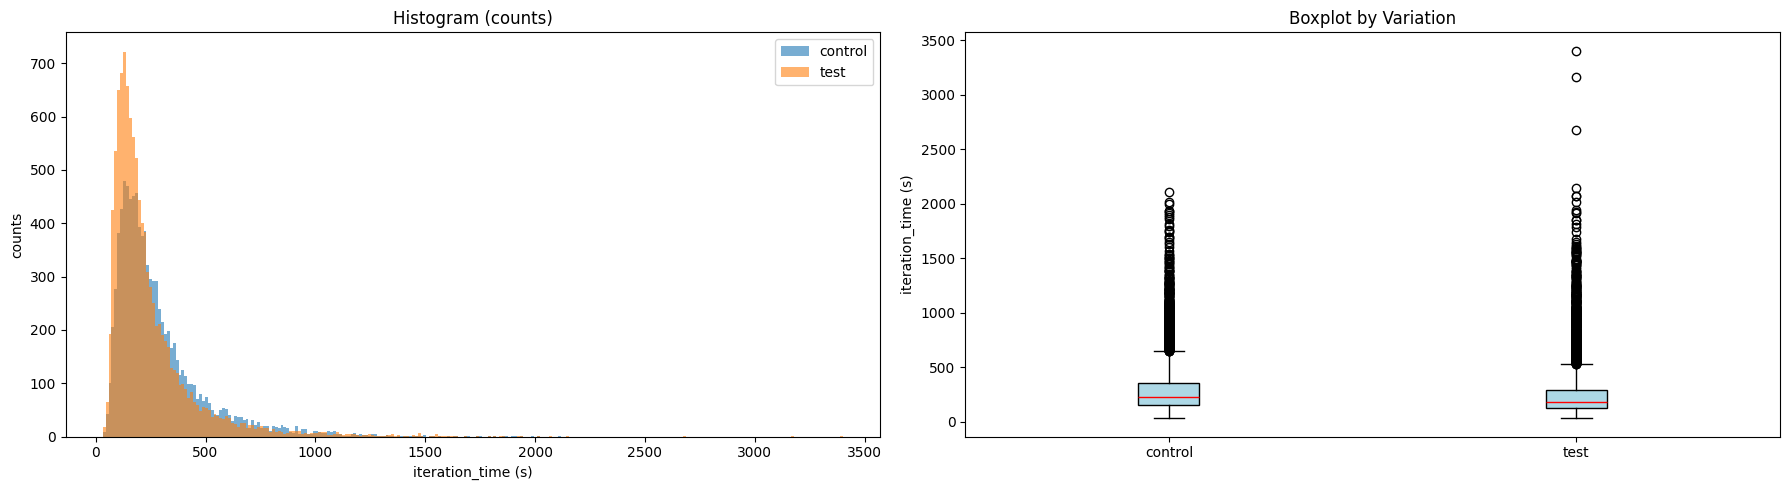

In [59]:
import matplotlib.pyplot as plt
import numpy as np

df = dfGEnius_time.copy()
df = df.dropna(subset=['iteration_time'])
df['Variation'] = df['Variation'].astype(str).str.lower()

test = df[df['Variation']=='test']['iteration_time'].astype(float)
control = df[df['Variation']=='control']['iteration_time'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(18,5))

bins = np.histogram_bin_edges(df['iteration_time'], bins='auto')
axes[0].hist(control, bins=bins, alpha=0.6, label='control', color='C0', histtype='stepfilled')
axes[0].hist(test, bins=bins, alpha=0.6, label='test', color='C1', histtype='stepfilled')
axes[0].set_xlabel('iteration_time (s)')
axes[0].set_ylabel('counts')
axes[0].set_title('Histogram (counts)')
axes[0].legend()

axes[1].boxplot([control, test], labels=['control','test'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
axes[1].set_ylabel('iteration_time (s)')
axes[1].set_title('Boxplot by Variation')


plt.tight_layout()
plt.savefig('iteration_time_plots_counts.png', dpi=150)
plt.show()



In [60]:

from scipy import stats
# H0: The mean iteration_time in the test group is equal to the mean iteration_time in the control group
# H1: The means differ (two-tailed alternative)

test_times = dfGEnius_time[dfGEnius_time['Variation']=='test']['iteration_time'].astype(float).values
ctrl_times = dfGEnius_time[dfGEnius_time['Variation']=='control']['iteration_time'].astype(float).values

stats.ttest_ind(test_times, ctrl_times, equal_var=False, nan_policy='omit')

# rejecting H0

TtestResult(statistic=np.float64(-14.474444962750246), pvalue=np.float64(3.0772587023038835e-47), df=np.float64(19635.584121561402))